In [1]:
# Libaries
import matplotlib as mpl
import matplotlib.pyplot as plt
import scienceplots
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
plt.style.use(["science", "no-latex"])
import torch
import gpytorch
torch.set_default_dtype(torch.float64)
import numpy as np
import warnings
import os
import cv2
import numpy as np
import shutil
import pandas as pd


# SmallsatSim stuff
from smallsat_sim.utils.logger import Logger
import matplotlib.pyplot as plt

# Zero Order GPMPC package stuff
from zero_order_gpmpc.models.gpytorch_models.gpytorch_gp import (
    BatchIndependentMultitaskGPModel,
)

In [2]:
# Define some matplotlib parameters
# Use LaTeX for rendering text in plots
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.size'] = 12  # Adjust as needed
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

Training the model on the full dataset...
Training complete.


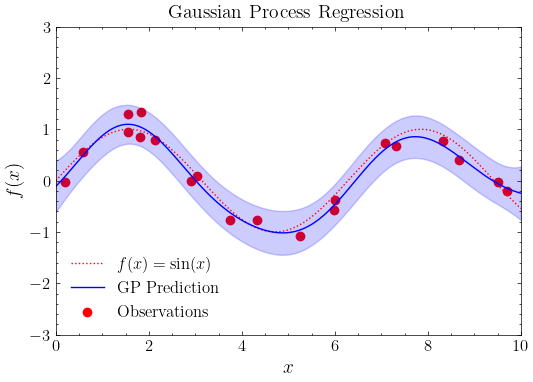

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import torch
import gpytorch

# Set the random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Define the true function
def f(x):
    return np.sin(x)

# Generate random x locations for observations
X_full_np = np.random.uniform(0, 10, 20)
y_full_np = f(X_full_np) + np.random.normal(0, 0.2, X_full_np.shape[0])

# Randomize the order in which data points are added
indices = np.arange(len(X_full_np))
np.random.shuffle(indices)
X_full_np_shuffled = X_full_np[indices]
y_full_np_shuffled = y_full_np[indices]

# Convert data to torch tensors
X_full = torch.from_numpy(X_full_np_shuffled).float()
y_full = torch.from_numpy(y_full_np_shuffled).float()

# Mesh the input space for predictions
x_pred_np = np.linspace(0, 10, 1000)
x_pred = torch.from_numpy(x_pred_np).float().unsqueeze(-1)

# Initialize empty tensors for observations
X = torch.tensor([]).float()
y = torch.tensor([]).float()

# Define the GP Model
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x_shape, likelihood):
        super(ExactGPModel, self).__init__(None, None, likelihood)
        # Define the mean and covariance functions
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        # Placeholder for training data
        self.train_inputs = None
        self.train_targets = None

    def set_train_data(self, inputs=None, targets=None, strict=True):
        if inputs is not None and targets is not None:
            self.train_inputs = (inputs,)
            self.train_targets = targets

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x_shape=(len(X_full), 1), likelihood=likelihood)

# Prepare the full dataset for training
model.set_train_data(inputs=X_full.unsqueeze(-1), targets=y_full, strict=False)

# Train the model once on the full dataset to learn hyperparameters
model.train()
likelihood.train()

# Use the Adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)

# Loss function
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

print("Training the model on the full dataset...")
# Training loop
training_iterations = 100
for _ in range(training_iterations):
    optimizer.zero_grad()
    output = model(model.train_inputs[0])
    loss = -mll(output, model.train_targets)
    loss.backward()
    optimizer.step()

print("Training complete.")

# Set the model to evaluation mode
model.eval()
likelihood.eval()

# Now we can use the trained hyperparameters and update the predictions as new data is added
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
line_true, = ax.plot(x_pred_np, f(x_pred_np), 'r:', label=r'$f(x) = \sin(x)$')
line_pred, = ax.plot([], [], 'b-', label='GP Prediction')
scatter_obs = ax.scatter([], [], c='r', label='Observations')
fill_between = None
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Gaussian Process Regression')
ax.legend(loc='lower left')

# Initialize plot limits
ax.set_xlim(0, 10)
ax.set_ylim(-3, 3)

def init():
    line_pred.set_data([], [])
    scatter_obs.set_offsets(np.empty((0, 2)))
    global fill_between
    if fill_between is not None:
        fill_between.remove()
        fill_between = None  # Reset to None after removing
    return line_pred, scatter_obs

def animate(i):
    global X, y, fill_between

    # Add the next data point
    X = X_full[:i+1].unsqueeze(-1)  # Use data up to index i
    y = y_full[:i+1]

    # Update model with new data (but do not retrain hyperparameters)
    model.set_train_data(inputs=X, targets=y, strict=False)
    model.prediction_strategy = None  # Reset prediction strategy
    model.eval()
    likelihood.eval()

    # Make predictions
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(x_pred))

    y_pred = observed_pred.mean.numpy()
    sigma = observed_pred.stddev.numpy()

    # Update the GP prediction line
    line_pred.set_data(x_pred_np, y_pred)

    # Update the observations
    scatter_obs.set_offsets(np.vstack((X.squeeze().numpy(), y.numpy())).T)

    # Update the confidence interval
    if fill_between is not None:
        fill_between.remove()
        fill_between = None  # Reset to None after removing

    fill_between = ax.fill_between(x_pred_np, y_pred - 2 * sigma, y_pred + 2 * sigma,
                                   alpha=0.2, color='blue')

    return line_pred, scatter_obs, fill_between

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=len(X_full), init_func=init,
                              blit=False, interval=500, repeat=False)

# To save the animation as a video file, uncomment the following lines:
Writer = animation.writers['ffmpeg']
writer = Writer(fps=2, metadata=dict(artist='Me'), bitrate=6000)
ani.save('gpytorch_regression_animation.mp4', writer=writer)

plt.show()
